# Spectral Co-Clustering for Olist SP 2017
This notebook runs the local spectral clustering implementation in `models/` using the `modeling_config.yaml` configuration and the SP 2017 featurization output.

In [1]:
import sys
from pathlib import Path

workspace_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(workspace_root))
from models.spectral_clustering import run_spectral_clustering

config_path = workspace_root / 'modeling_config.yaml'
if not config_path.exists():
    raise FileNotFoundError(f'Model config not found: {config_path}')

output_dir = workspace_root / 'models'
results = run_spectral_clustering(str(config_path), output_dir=str(output_dir))
print('Spectral clustering completed. Artifacts:')
for name, path in results.items():
    print(f'- {name}: {path}')

Spectral clustering completed. Artifacts:
- spectral_gap: /home/rajiv/programming/kmds_migration/olist_migration/models/spectral_gap.csv
- week_clusters: /home/rajiv/programming/kmds_migration/olist_migration/models/week_clusters.csv
- product_clusters: /home/rajiv/programming/kmds_migration/olist_migration/models/product_clusters.csv
- week_embeddings: /home/rajiv/programming/kmds_migration/olist_migration/models/week_embeddings.csv
- product_embeddings: /home/rajiv/programming/kmds_migration/olist_migration/models/product_embeddings.csv
- cluster_counts: /home/rajiv/programming/kmds_migration/olist_migration/models/cluster_counts.csv
- joint_embedding: /home/rajiv/programming/kmds_migration/olist_migration/models/joint_embedding.parquet
- summary: /home/rajiv/programming/kmds_migration/olist_migration/models/spectral_clustering_summary.md


In [2]:
import pandas as pd

spectral_gap = pd.read_csv(output_dir / 'spectral_gap.csv')
week_clusters = pd.read_csv(output_dir / 'week_clusters.csv')
product_clusters = pd.read_csv(output_dir / 'product_clusters.csv')
cluster_counts = pd.read_csv(output_dir / 'cluster_counts.csv')

print('Spectral gap analysis sample:')
print(spectral_gap.head(10).to_string(index=False))
print('\nWeek cluster counts:')
print(cluster_counts[['week_cluster']].head(10).to_string(index=False))
print('\nProduct cluster counts:')
print(cluster_counts[['product_cluster']].head(10).to_string(index=False))

week_clusters.head(), product_clusters.head()

Spectral gap analysis sample:
 component  singular_value       gap
         1        0.929740 -0.213220
         2        0.716520 -0.270105
         3        0.446415 -0.050845
         4        0.395570 -0.015721
         5        0.379850 -0.002514
         6        0.377335 -0.018220
         7        0.359115 -0.011166
         8        0.347949 -0.011848
         9        0.336100 -0.015239
        10        0.320862 -0.006147

Week cluster counts:
 week_cluster
           11
            0
            1
            0
            2
            1
            1
            0
            2
            3

Product cluster counts:
 product_cluster
            8661
               2
               0
               1
               1
              11
               0
               1
               1
              11


(   woy  cluster
 0    1        0
 1    2        2
 2    3       15
 3    4       12
 4    5        8,
                          product_id  cluster
 0  00088930e925c41fd95ebfe695fd2655        0
 1  0009406fd7479715e4bef61dd91f2462        0
 2  00126f27c813603687e6ce486d909d01        0
 3  001795ec6f1b187d37335e1c4704762e        0
 4  001b72dfd63e9833e8c02742adf472e3        0)

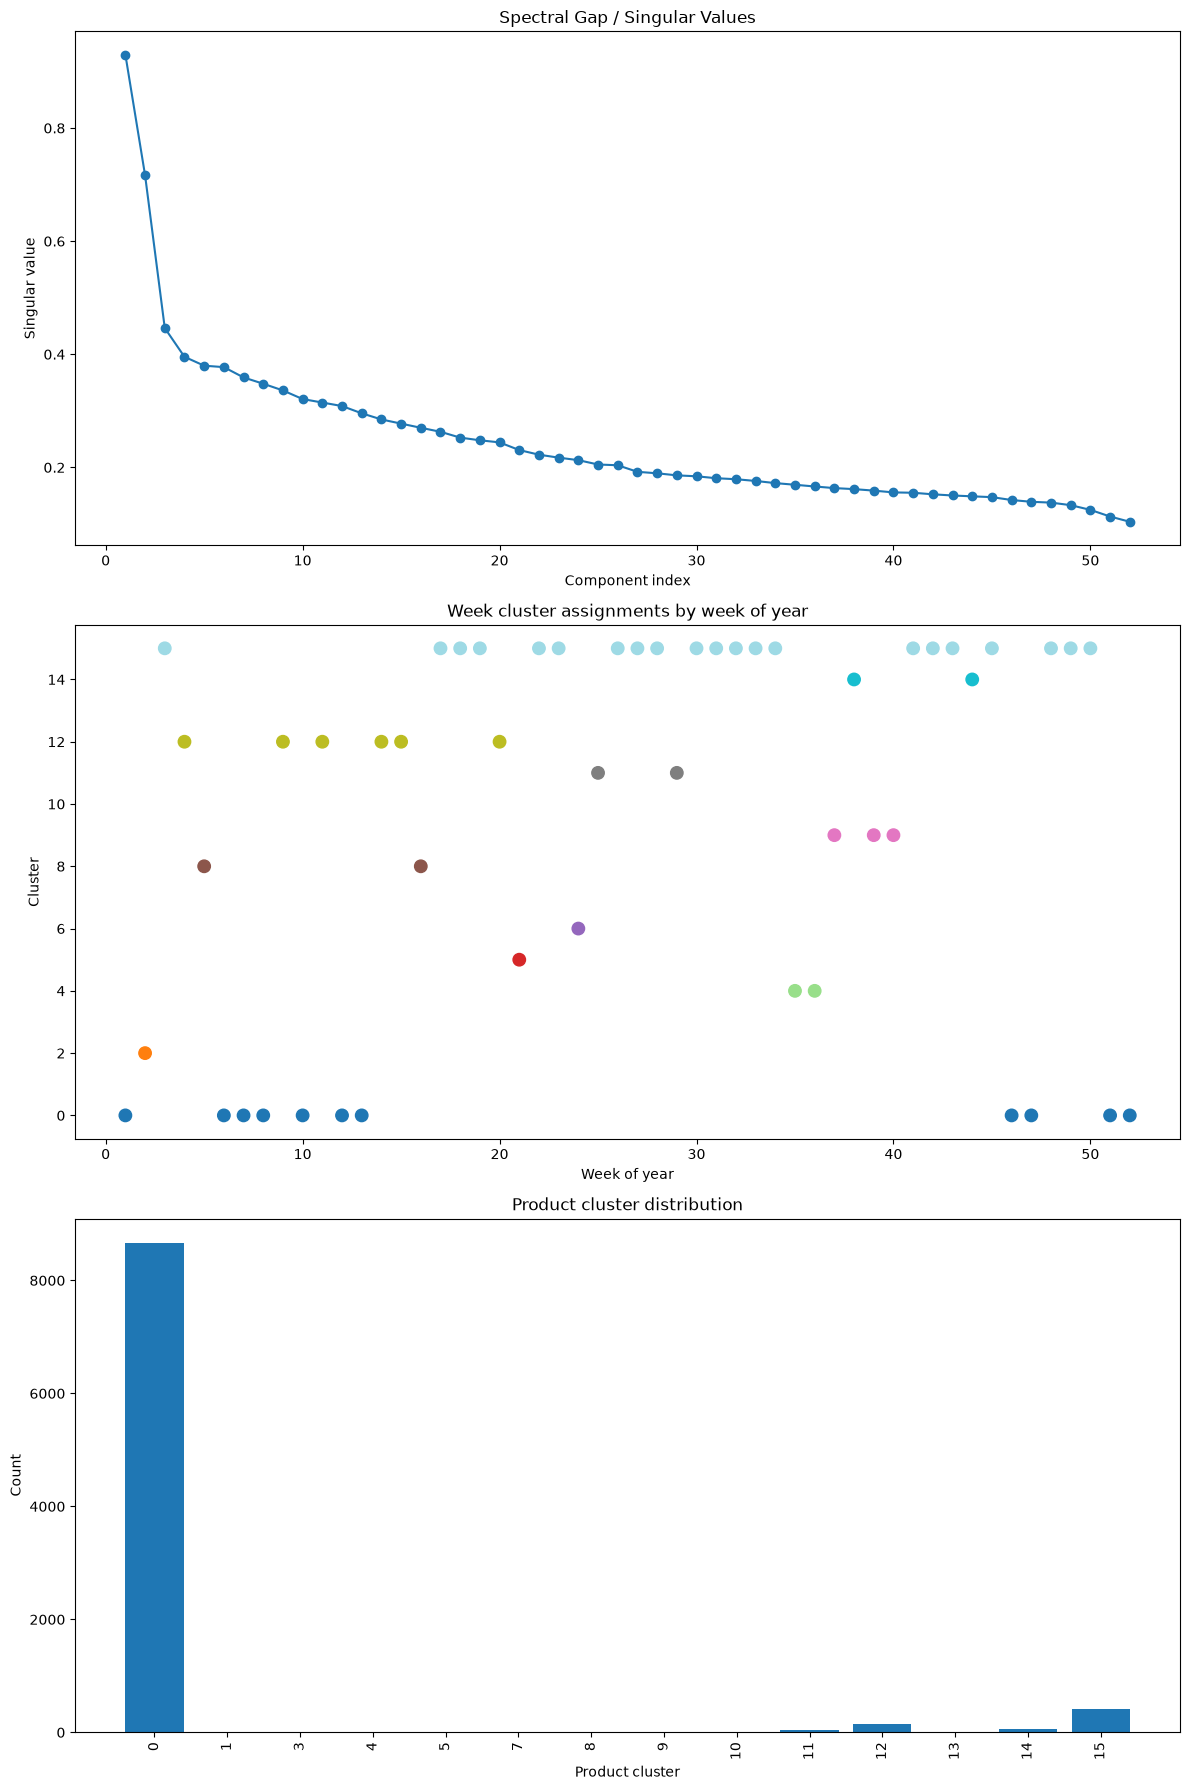

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

spectral_gap = pd.read_csv(output_dir / 'spectral_gap.csv')
cluster_counts = pd.read_csv(output_dir / 'cluster_counts.csv')
week_clusters = pd.read_csv(output_dir / 'week_clusters.csv')
product_clusters = pd.read_csv(output_dir / 'product_clusters.csv')

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
axes[0].plot(spectral_gap['component'], spectral_gap['singular_value'], marker='o', linestyle='-')
axes[0].set_title('Spectral Gap / Singular Values')
axes[0].set_xlabel('Component index')
axes[0].set_ylabel('Singular value')

week_sorted = week_clusters.sort_values('woy')
axes[1].scatter(week_sorted['woy'], week_sorted['cluster'], c=week_sorted['cluster'], cmap='tab20', s=80)
axes[1].set_title('Week cluster assignments by week of year')
axes[1].set_xlabel('Week of year')
axes[1].set_ylabel('Cluster')

product_counts = product_clusters['cluster'].value_counts().sort_index()
axes[2].bar(product_counts.index.astype(str), product_counts.values, color='tab:blue')
axes[2].set_title('Product cluster distribution')
axes[2].set_xlabel('Product cluster')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## Notes
- The model reads the SP 2017 product-week matrix from the featurization output and produces clustering artifacts under `models/`.
- The algorithm uses normalized bipartite spectral co-clustering, consistent with the local rationale for spectral clustering.
- The notebook output includes a spectral gap analysis, week cluster labels, product cluster labels, and cluster-size summaries.